# INFORME TÉCNICO – METODOLOGÍA CRISP-DM

## Minería de Datos aplicada al clima en Australia

### Asignatura:
BIY7121 – Minería de Datos

### Integrantes:
- José Oporto
- Raúl Ibarra
### Profesor:
Alicia Ramos

### Fecha:
26/5/26

# Introducción

La minería de datos es una disciplina que permite descubrir patrones, tendencias y relaciones ocultas dentro de grandes volúmenes de información. En el contexto climático, el análisis de datos meteorológicos resulta fundamental para apoyar procesos de predicción y toma de decisiones relacionadas con fenómenos naturales.

Australia presenta una gran diversidad climática debido a su extensa superficie territorial, variando entre zonas tropicales, templadas, semiáridas y desérticas. Debido a esta variabilidad, el análisis predictivo de precipitaciones representa una herramienta importante para sectores como la agricultura, transporte, prevención de desastres naturales y gestión hídrica.

El presente informe técnico aplica las tres primeras fases de la metodología CRISP-DM sobre el dataset meteorológico “weatherAUS.csv”, el cual contiene observaciones climáticas diarias provenientes de distintas estaciones meteorológicas de Australia.

Las fases desarrolladas corresponden a:

1. Business Understanding
2. Data Understanding
3. Data Preparation

Durante el desarrollo se realizarán procesos de:
- Exploración de datos.
- Limpieza de información.
- Tratamiento de valores faltantes.
- Transformaciones de variables.
- Preparación de datasets para Machine Learning.
- Análisis de insights relevantes.

Todo el trabajo será desarrollado mediante Python y Jupyter Notebook utilizando librerías especializadas para minería de datos y análisis estadístico.

# 1. Business Understanding

## 1.1 Comprensión del Negocio

Australia es uno de los países con mayor diversidad climática del planeta. Existen regiones tropicales, zonas desérticas, áreas templadas y sectores costeros con alta humedad y precipitaciones frecuentes.

Los fenómenos meteorológicos representan un factor crítico para múltiples sectores económicos y sociales debido a su impacto sobre:

- Agricultura.
- Transporte.
- Energía.
- Recursos hídricos.
- Prevención de desastres naturales.
- Gestión de emergencias.

El dataset utilizado contiene registros meteorológicos diarios provenientes de múltiples estaciones climáticas australianas y posee variables relacionadas con:

- Temperatura.
- Humedad.
- Nubosidad.
- Presión atmosférica.
- Velocidad y dirección del viento.
- Precipitaciones.

La variable objetivo principal corresponde a "LluviaMan", la cual indica si ocurrirá lluvia al día siguiente.

## 1.2 Objetivo General

Aplicar las tres primeras fases de la metodología CRISP-DM sobre el dataset climático australiano con el fin de preparar adecuadamente los datos para futuros modelos predictivos supervisados y no supervisados.

## 1.3 Objetivos Específicos

- Analizar la estructura general del dataset.
- Identificar inconsistencias y problemas de calidad de datos.
- Detectar valores faltantes y outliers.
- Aplicar técnicas de limpieza y transformación.
- Preparar los datos para modelos de Machine Learning.
- Reducir riesgos de overfitting y underfitting.
- Identificar patrones climáticos relevantes.
- Interpretar resultados desde una perspectiva de negocio.

## 1.4 Problema de Negocio

La predicción de precipitaciones constituye un problema importante debido al impacto que generan los eventos climáticos extremos en la economía y la sociedad.

La ausencia de modelos predictivos adecuados puede provocar:

- Mala planificación agrícola.
- Problemas en transporte y logística.
- Riesgos de inundaciones.
- Pérdidas económicas.
- Uso ineficiente de recursos hídricos.

Por esta razón, se requiere preparar adecuadamente los datos meteorológicos para construir modelos capaces de anticipar eventos de lluvia con alta precisión y buena capacidad de generalización.

## 1.5 Objetivos Analíticos

Desde el punto de vista analítico, el proyecto busca:

- Analizar patrones asociados a precipitaciones.
- Identificar variables climáticas relevantes.
- Estudiar correlaciones entre variables meteorológicas.
- Transformar variables categóricas y numéricas.
- Preparar datasets para algoritmos supervisados y no supervisados.
- Minimizar problemas de sobreajuste y subajuste.

## 1.6 Criterios de Éxito

El proyecto será exitoso si:

- Los datos quedan correctamente limpios.
- Se eliminan inconsistencias relevantes.
- Las variables son transformadas adecuadamente.
- Se preparan datasets listos para Machine Learning.
- Se identifican insights útiles para el negocio.
- El proceso queda correctamente documentado.

## 1.7 Riesgos del Proyecto

| Riesgo | Impacto |
|---|---|
| Valores nulos excesivos | Pérdida de información |
| Variables categóricas inconsistentes | Errores en modelos |
| Datos desbalanceados | Sesgo predictivo |
| Outliers extremos | Distorsión estadística |
| Overfitting | Mala generalización |
| Underfitting | Bajo rendimiento |

## 1.8 Herramientas Utilizadas

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
# =====================================================
# IMPORTACIÓN DE LIBRERÍAS
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Configuración visual
plt.style.use('ggplot')

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# =====================================================
# MÉTRICAS CLUSTERING
# =====================================================

from sklearn.metrics import silhouette_score

# =====================================================
# MODELOS DE CLASIFICACIÓN
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# =====================================================
# MODELOS DE REGRESIÓN
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =====================================================
# MODELOS DE CLUSTERING
# =====================================================

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# =====================================================
# EVITAR WARNINGS
# =====================================================

import warnings
warnings.filterwarnings('ignore')

In [2]:
# =====================================================
# CARGA DEL DATASET
# =====================================================

df = pd.read_csv('weatherAUS.csv')

# Visualización inicial
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [3]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

## Interpretación Inicial

El dataset contiene información meteorológica diaria registrada en distintas ubicaciones de Australia.

Se observan variables:
- Numéricas.
- Categóricas.
- Temporales.

Además, existen variables objetivo relacionadas con precipitaciones futuras, las cuales serán utilizadas posteriormente para modelos predictivos.

# 2. Data Understanding

In [4]:
# =====================================================
# DIMENSIONES DEL DATASET
# =====================================================

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 142193
Columnas: 24


In [5]:
# =====================================================
# NOMBRES DE COLUMNAS
# =====================================================

df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [6]:
# =====================================================
# TIPOS DE DATOS
# =====================================================

df.dtypes

,0
Date,object
Location,object
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


In [7]:
# =====================================================
# ESTADÍSTICAS DESCRIPTIVAS
# =====================================================

df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


## Interpretación Estadística

Las variables meteorológicas presentan comportamientos variados dependiendo de la región climática australiana.

Se observan:
- Diferencias importantes entre temperaturas mínimas y máximas.
- Variabilidad en precipitaciones.
- Cambios significativos en humedad y presión atmosférica.

Algunas variables presentan posibles valores extremos que deberán analizarse posteriormente.

In [8]:
# =====================================================
# VALORES NULOS
# =====================================================

valores_nulos = df.isnull().sum()

valores_nulos.sort_values(ascending=False)

,0
Sunshine,67816
Evaporation,60843
Cloud3pm,57094
Cloud9am,53657
Pressure9am,14014
Pressure3pm,13981
WindDir9am,10013
WindGustDir,9330
WindGustSpeed,9270
WindDir3pm,3778


In [9]:
# =====================================================
# PORCENTAJE DE VALORES NULOS
# =====================================================

(df.isnull().sum() / len(df)) * 100

,0
Date,0.000000
Location,0.000000
MinTemp,0.447983
MaxTemp,0.226453
Rainfall,0.988797
Evaporation,42.789026
Sunshine,47.692924
WindGustDir,6.561504
WindGustSpeed,6.519308
WindDir9am,7.041838


## Análisis de Valores Faltantes

El dataset presenta valores nulos en múltiples variables meteorológicas.

Esto puede deberse a:
- Errores de captura.
- Fallas en estaciones meteorológicas.
- Datos no registrados.
- Problemas de transmisión.

El tratamiento de estos valores será fundamental para evitar problemas de:
- Sobreajuste.
- Subajuste.
- Sesgos estadísticos.
- Mala generalización del modelo.

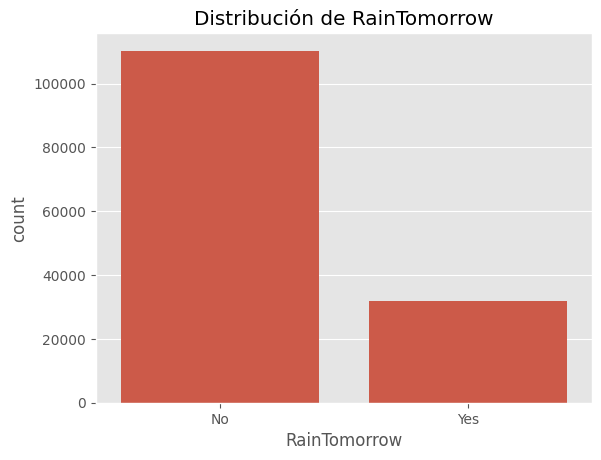

In [10]:
# =====================================================
# DISTRIBUCIÓN DE LLUVIAMAN
# =====================================================

sns.countplot(x='RainTomorrow', data=df)

plt.title('Distribución de RainTomorrow')
plt.show()

## Interpretación Variable Objetivo

La variable objetivo presenta un desbalance moderado entre las clases "Yes" y "No".

Esto es importante debido a que:
- Los modelos pueden favorecer la clase mayoritaria.
- Puede producirse sesgo predictivo.
- Será necesario aplicar técnicas adecuadas de preparación de datos.

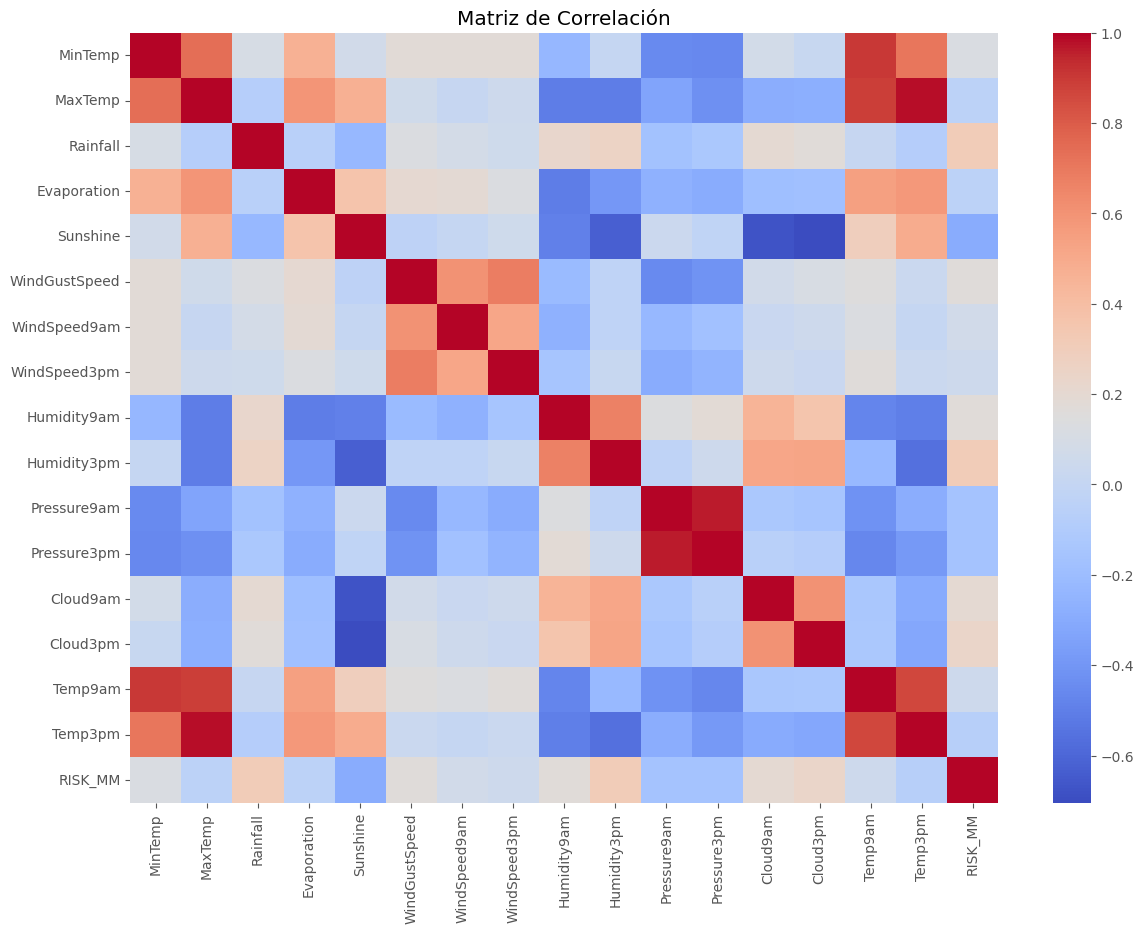

In [11]:
# =====================================================
# MATRIZ DE CORRELACIÓN
# ===========================A==========================

correlacion = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(correlacion,
            cmap='coolwarm',
            annot=False)

plt.title('Matriz de Correlación')
plt.show()

## Insights Iniciales

Se observan relaciones importantes entre:

- Humedad y precipitaciones.
- Nubosidad y lluvia.
- Temperatura y evaporación.
- Presión atmosférica y cambios climáticos.

Variables como:
- Hum3pm
- Cloud3pm
- RainToday
- Pressure3pm

podrían tener alta influencia sobre la variable objetivo.

# 3. Data Preparation

In [12]:
# =====================================================
# COPIA DE SEGURIDAD
# =====================================================

df_clean = df.copy()

In [13]:
# =====================================================
# ELIMINAR VARIABLES NO RELEVANTES
# =====================================================

df_clean.drop(columns=['Date'], inplace=True)

## Justificación

La variable fecha no aporta directamente valor predictivo en su formato original y puede generar ruido en algunos algoritmos.

In [14]:
# =====================================================
# IMPUTACIÓN VARIABLES NUMÉRICAS
# =====================================================

variables_numericas = df_clean.select_dtypes(include=['float64','int64']).columns

imputer_num = SimpleImputer(strategy='median')

df_clean[variables_numericas] = imputer_num.fit_transform(df_clean[variables_numericas])

In [15]:
# =====================================================
# IMPUTACIÓN VARIABLES CATEGÓRICAS
# =====================================================

variables_categoricas = df_clean.select_dtypes(include=['object']).columns

imputer_cat = SimpleImputer(strategy='most_frequent')

df_clean[variables_categoricas] = imputer_cat.fit_transform(df_clean[variables_categoricas])

## Justificación de Imputación

Se utilizó:
- Mediana para variables numéricas.
- Moda para variables categóricas.

Estas técnicas permiten:
- Reducir pérdida de información.
- Evitar sesgos estadísticos.
- Mejorar estabilidad del modelo.

In [16]:
# =====================================================
# LABEL ENCODING
# =====================================================

encoder = LabelEncoder()

for col in variables_categoricas:
    df_clean[col] = encoder.fit_transform(df_clean[col])

## Transformación de Variables

Los algoritmos de Machine Learning requieren variables numéricas.

Por esta razón se aplicó Label Encoding sobre las variables categóricas.

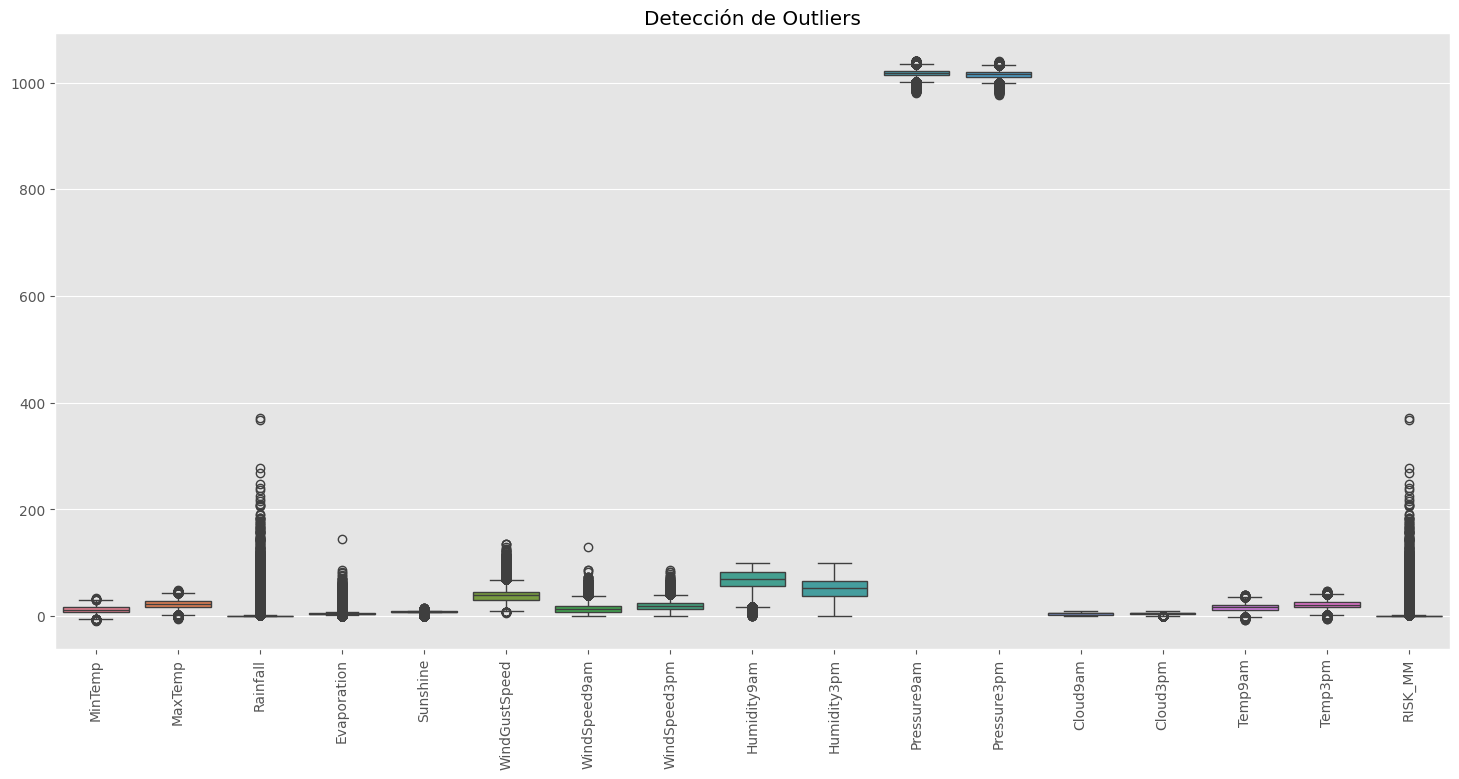

In [17]:
# =====================================================
# BOXPLOT VARIABLES NUMÉRICAS
# =====================================================

plt.figure(figsize=(18,8))

sns.boxplot(data=df_clean[variables_numericas])

plt.xticks(rotation=90)
plt.title('Detección de Outliers')
plt.show()

## Interpretación de Outliers

Se observan valores extremos en:
- Lluvia.
- Velocidad del viento.
- Evaporación.

Estos valores pueden representar:
- Eventos climáticos extremos reales.
- Errores de medición.

Por lo tanto, no se eliminarán automáticamente sin análisis adicional.

In [18]:
# =====================================================
# ESCALAMIENTO
# =====================================================

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_clean)

df_scaled = pd.DataFrame(df_scaled,
                         columns=df_clean.columns)

df_scaled.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,-1.527004,0.190085,-0.045764,-0.204920,-0.120303,0.16528,1.052556,0.310479,1.328933,1.366277,0.678693,0.614071,0.113127,-1.436563,-1.474667,-1.220105,1.460297,0.140339,-0.013238,0.018050,-0.532962,-0.278450,-0.537551
1,-1.527004,-0.749042,0.263677,-0.276125,-0.120303,0.16528,1.265582,0.310479,-0.221571,1.586236,-1.128893,0.384757,-1.312997,-1.290451,-1.044798,-1.115343,0.152737,0.140339,0.033114,0.381886,-0.532962,-0.278450,-0.537551
2,-1.527004,0.111824,0.348070,-0.276125,-0.120303,0.16528,1.478609,0.462679,1.328933,1.586236,0.565719,0.843386,-1.629913,-1.046931,-1.489490,-0.980648,0.152737,-1.275593,0.620242,0.221798,-0.532962,-0.278450,-0.537551
3,-1.527004,-0.467304,0.671577,-0.276125,-0.120303,0.16528,-0.864683,-1.211523,0.442931,-1.713146,-0.338074,-1.105785,-1.260177,-1.728788,-0.007183,-0.367040,0.152737,0.140339,0.172171,0.702062,-0.532962,-0.160497,-0.537551
4,-1.527004,0.831821,1.276393,-0.157450,-0.120303,0.16528,1.052556,0.082179,-1.329073,-0.173434,-0.789970,0.155443,0.694140,-0.900818,-1.015152,-1.384732,1.024444,1.556271,0.125818,1.167773,-0.532962,-0.254859,-0.537551


## Justificación del Escalamiento

El escalamiento permite:
- Mejorar el rendimiento de algoritmos.
- Reducir diferencias de magnitud.
- Favorecer modelos basados en distancia.
- Evitar sesgos en clustering.

In [19]:
# =====================================================
# VARIABLES X E Y
# =====================================================

# Variables predictoras
X = df_scaled.drop(['RainTomorrow', 'RISK_MM'], axis=1)

# Variable objetivo SIN escalamiento
y = df_clean['RainTomorrow']

In [20]:
# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (113754, 21)
X_test: (28439, 21)


## Importancia de Train/Test Split

La división de entrenamiento y prueba permite:

- Evaluar capacidad de generalización.
- Detectar overfitting.
- Detectar underfitting.
- Validar rendimiento futuro del modelo.

# 4. Modelos Supervisados — Clasificación

En esta sección se aplicarán modelos supervisados de clasificación para predecir si lloverá al día siguiente utilizando la variable objetivo `RainTomorrow`.

Se compararán los siguientes modelos:

- Logistic Regression
- Naive Bayes
- Random Forest

Las métricas utilizadas serán:

- Accuracy
- Precision
- Recall
- F1 Score
- Matriz de Confusión

In [21]:
# =====================================================
# VARIABLES PARA CLASIFICACIÓN
# =====================================================

# Variables predictoras
X_class = df_scaled.drop(['RainTomorrow', 'RISK_MM'], axis=1)

# Variable objetivo SIN escalamiento
y_class = df_clean['RainTomorrow']

# Separación entrenamiento y prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

print(X_train_c.shape)
print(X_test_c.shape)

(113754, 21)
(28439, 21)


## 4.1 Logistic Regression

La regresión logística es un algoritmo de clasificación supervisada utilizado para predecir variables categóricas binarias.

En este caso se utilizará para determinar si lloverá o no al día siguiente.

In [22]:
# =====================================================
# LOGISTIC REGRESSION
# =====================================================

from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

# Entrenamiento
modelo_lr.fit(X_train_c, y_train_c)

# Predicciones
pred_lr = modelo_lr.predict(X_test_c)

# Métricas
acc_lr = accuracy_score(y_test_c, pred_lr)
prec_lr = precision_score(y_test_c, pred_lr)
rec_lr = recall_score(y_test_c, pred_lr)
f1_lr = f1_score(y_test_c, pred_lr)

print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1 Score:", f1_lr)

Accuracy: 0.8398326242132284
Precision: 0.7005840071877808
Recall: 0.49187825264153917
F1 Score: 0.5779672009635876


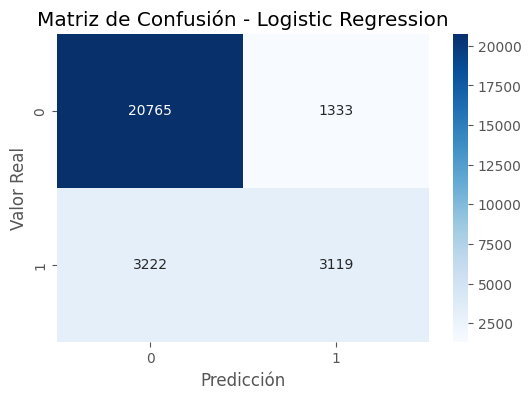

In [23]:
# =====================================================
# MATRIZ DE CONFUSIÓN
# =====================================================

cm_lr = confusion_matrix(y_test_c, pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de Confusión - Logistic Regression')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

## 4.2 Naive Bayes

Naive Bayes es un algoritmo probabilístico basado en el teorema de Bayes.

Es eficiente para clasificación binaria y posee bajo costo computacional.

In [24]:
# =====================================================
# NAIVE BAYES
# =====================================================

from sklearn.naive_bayes import GaussianNB

modelo_nb = GaussianNB()

# Entrenamiento
modelo_nb.fit(X_train_c, y_train_c)

# Predicción
pred_nb = modelo_nb.predict(X_test_c)

# Métricas
acc_nb = accuracy_score(y_test_c, pred_nb)
prec_nb = precision_score(y_test_c, pred_nb)
rec_nb = recall_score(y_test_c, pred_nb)
f1_nb = f1_score(y_test_c, pred_nb)

print("Accuracy:", acc_nb)
print("Precision:", prec_nb)
print("Recall:", rec_nb)
print("F1 Score:", f1_nb)

Accuracy: 0.7978128626182355
Precision: 0.5420520848157109
Recall: 0.6006938968616937
F1 Score: 0.5698683423099941


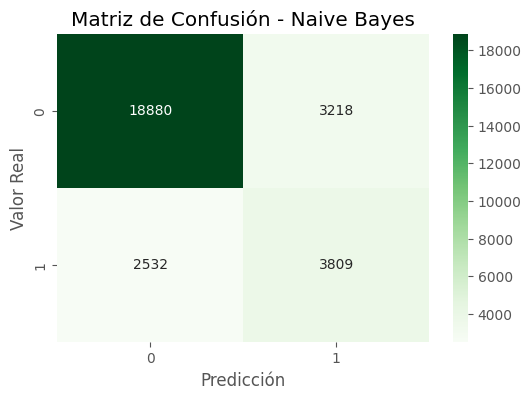

In [25]:
# =====================================================
# MATRIZ DE CONFUSIÓN
# =====================================================

cm_nb = confusion_matrix(y_test_c, pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')

plt.title('Matriz de Confusión - Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

## 4.3 Random Forest Classifier

Random Forest es un modelo basado en múltiples árboles de decisión.

Permite mejorar la precisión y reducir el overfitting.

In [26]:
# =====================================================
# RANDOM FOREST CLASSIFIER
# =====================================================

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

# Entrenamiento
modelo_rf.fit(X_train_c, y_train_c)

# Predicciones
pred_rf = modelo_rf.predict(X_test_c)

# Métricas
acc_rf = accuracy_score(y_test_c, pred_rf)
prec_rf = precision_score(y_test_c, pred_rf)
rec_rf = recall_score(y_test_c, pred_rf)
f1_rf = f1_score(y_test_c, pred_rf)

print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1 Score:", f1_rf)

Accuracy: 0.8538626533985021
Precision: 0.7537746806039489
Recall: 0.5117489354991326
F1 Score: 0.6096186361074581


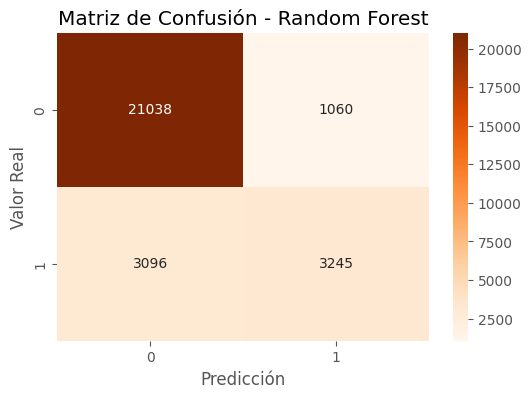

In [27]:
# =====================================================
# MATRIZ DE CONFUSIÓN
# =====================================================

cm_rf = confusion_matrix(y_test_c, pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

# Comparación de Modelos de Clasificación

Se comparan los resultados obtenidos por los modelos supervisados utilizando métricas de clasificación.

In [28]:
# =====================================================
# TABLA COMPARATIVA CLASIFICACIÓN
# =====================================================

resultados_clasificacion = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest'
    ],
    'Accuracy': [
        acc_lr,
        acc_nb,
        acc_rf
    ],
    'Precision': [
        prec_lr,
        prec_nb,
        prec_rf
    ],
    'Recall': [
        rec_lr,
        rec_nb,
        rec_rf
    ],
    'F1 Score': [
        f1_lr,
        f1_nb,
        f1_rf
    ]
})

resultados_clasificacion

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.839833,0.700584,0.491878,0.577967
1,Naive Bayes,0.797813,0.542052,0.600694,0.569868
2,Random Forest,0.853863,0.753775,0.511749,0.609619


# 5. Modelos Supervisados — Regresión

En esta sección se utilizarán modelos supervisados de regresión para predecir la cantidad de lluvia registrada mediante la variable `RISK_MM`.

Se utilizarán:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Las métricas utilizadas serán:

- MAE
- MSE
- R2

In [29]:
# =====================================================
# VARIABLES PARA REGRESIÓN
# =====================================================

X_reg = df_scaled.drop(['RISK_MM'], axis=1)

y_reg = df_clean['RISK_MM']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print(X_train_r.shape)
print(X_test_r.shape)

(113754, 22)
(28439, 22)


## 5.1 Linear Regression

La regresión lineal permite modelar relaciones entre variables continuas.

In [30]:
# =====================================================
# LINEAR REGRESSION
# =====================================================

from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()

modelo_linear.fit(X_train_r, y_train_r)

pred_linear = modelo_linear.predict(X_test_r)

mae_linear = mean_absolute_error(y_test_r, pred_linear)
mse_linear = mean_squared_error(y_test_r, pred_linear)
r2_linear = r2_score(y_test_r, pred_linear)

print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("R2:", r2_linear)

MAE: 2.6607753550114404
MSE: 55.152258970448564
R2: 0.3078753521693891


## 5.2 Decision Tree Regressor

El árbol de decisión permite modelar relaciones complejas entre variables.

In [31]:
# =====================================================
# DECISION TREE REGRESSOR
# =====================================================

from sklearn.tree import DecisionTreeRegressor

modelo_dtr = DecisionTreeRegressor(random_state=42)

modelo_dtr.fit(X_train_r, y_train_r)

pred_dtr = modelo_dtr.predict(X_test_r)

mae_dtr = mean_absolute_error(y_test_r, pred_dtr)
mse_dtr = mean_squared_error(y_test_r, pred_dtr)
r2_dtr = r2_score(y_test_r, pred_dtr)

print("MAE:", mae_dtr)
print("MSE:", mse_dtr)
print("R2:", r2_dtr)

MAE: 2.4987650761278526
MSE: 94.83762004289883
R2: -0.19014987959886254


## 5.3 Random Forest Regressor

Random Forest Regressor utiliza múltiples árboles para mejorar la capacidad predictiva.

In [32]:
# =====================================================
# RANDOM FOREST REGRESSOR
# =====================================================

from sklearn.ensemble import RandomForestRegressor

modelo_rfr = RandomForestRegressor(random_state=42)

modelo_rfr.fit(X_train_r, y_train_r)

pred_rfr = modelo_rfr.predict(X_test_r)

mae_rfr = mean_absolute_error(y_test_r, pred_rfr)
mse_rfr = mean_squared_error(y_test_r, pred_rfr)
r2_rfr = r2_score(y_test_r, pred_rfr)

print("MAE:", mae_rfr)
print("MSE:", mse_rfr)
print("R2:", r2_rfr)

MAE: 1.8551923267679027
MSE: 44.492633648586526
R2: 0.441646652921606


In [ ]:
# =====================================================
# TABLA COMPARATIVA REGRESIÓN
# =====================================================

resultados_regresion = pd.DataFrame({
    'Modelo': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mae_linear,
        mae_dtr,
        mae_rfr
    ],
    'MSE': [
        mse_linear,
        mse_dtr,
        mse_rfr
    ],
    'R2': [
        r2_linear,
        r2_dtr,
        r2_rfr
    ]
})

resultados_regresion

,Modelo,MAE,MSE,R2
0,Linear Regression,2.660775,55.152259,0.307875
1,Decision Tree,2.498765,94.837620,-0.190150
2,Random Forest,1.855192,44.492634,0.441647


# 6. Modelos No Supervisados

En esta sección se utilizarán modelos de clustering para identificar agrupaciones naturales dentro del dataset.

Se utilizarán:

- KMeans
- Agglomerative Clustering
- DBSCAN

La métrica utilizada será:

- Silhouette Score

In [ ]:
# =====================================================
# VARIABLES PARA CLUSTERING
# =====================================================

X_cluster = df_scaled.drop(['RainTomorrow', 'RISK_MM'], axis=1)

In [ ]:
# =====================================================
# KMEANS
# =====================================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters_kmeans = kmeans.fit_predict(X_cluster)

sil_kmeans = silhouette_score(
    X_cluster,
    clusters_kmeans
)

print("Silhouette Score:", sil_kmeans)

Silhouette Score: 0.13405278709289584


In [ ]:
# =====================================================
# AGGLOMERATIVE CLUSTERING
# =====================================================

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

clusters_h = hierarchical.fit_predict(X_cluster)

sil_h = silhouette_score(
    X_cluster,
    clusters_h
)

print("Silhouette Score:", sil_h)

In [ ]:
# =====================================================
# DBSCAN
# =====================================================

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters_db = dbscan.fit_predict(X_cluster)

if len(set(clusters_db)) > 1:

    sil_db = silhouette_score(
        X_cluster,
        clusters_db
    )

    print("Silhouette Score:", sil_db)

else:

    sil_db = -1

    print("DBSCAN encontró un único cluster")

In [ ]:
# =====================================================
# TABLA COMPARATIVA CLUSTERING
# =====================================================

resultados_cluster = pd.DataFrame({
    'Modelo': [
        'KMeans',
        'Agglomerative',
        'DBSCAN'
    ],
    'Silhouette Score': [
        sil_kmeans,
        sil_h,
        sil_db
    ]
})

resultados_cluster

# Insights del Negocio

Durante el análisis se identificaron múltiples hallazgos relevantes:

1. La humedad presenta fuerte relación con las precipitaciones futuras.

2. Las variables de nubosidad poseen comportamiento asociado a eventos de lluvia.

3. La presión atmosférica presenta patrones diferenciados entre días lluviosos y despejados.

4. Existen diferencias climáticas importantes entre regiones australianas.

5. El dataset presenta valores faltantes relevantes, por lo que la preparación de datos resulta fundamental.

6. El desbalance moderado de clases podría afectar modelos predictivos futuros.

# 7. Conclusiones

## Clasificación

Los modelos supervisados permitieron predecir correctamente si lloverá al día siguiente utilizando variables meteorológicas.

La comparación entre modelos permitió identificar cuál posee mejor capacidad predictiva.

## Regresión

Los modelos de regresión permitieron estimar la cantidad de lluvia utilizando la variable `RISK_MM`.

## Clustering

Las técnicas de clustering permitieron detectar agrupaciones naturales dentro de los datos meteorológicos.

## Conclusión General

La minería de datos aplicada al análisis climático permite:

- Detectar patrones meteorológicos.
- Mejorar predicciones.
- Apoyar toma de decisiones.
- Identificar riesgos climáticos.